In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

In [2]:
def normalizar_amostra(amostra, n, mi, sigma2):
    normal = np.sqrt(n)*(np.mean(amostra,axis=1)-mi)/np.sqrt(sigma2)
    return normal

### Uniforme


In [3]:
n = 1000
M = 5000

In [49]:
amostras_uniformes = np.random.uniform(size=(M,n))
amostra_normalizada = normalizar_amostra(amostras_uniformes, n, 0.5, 1/12)

In [50]:
df = pd.DataFrame(amostras_uniformes)
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.570763,0.766998,0.299785,0.412420,0.934297,0.398066,0.760338,0.454669,0.945189,0.779251,...,0.914540,0.945846,0.851333,0.167051,0.212075,0.690791,0.686453,0.756684,0.080811,0.412026
1,0.530469,0.303350,0.011843,0.281322,0.200664,0.248865,0.691289,0.921270,0.527433,0.430691,...,0.345492,0.654188,0.434386,0.539783,0.109947,0.580794,0.467983,0.183317,0.729634,0.279092
2,0.016104,0.895833,0.853529,0.793057,0.827835,0.408121,0.449579,0.872720,0.828442,0.661247,...,0.890671,0.849703,0.960384,0.988100,0.706003,0.563482,0.462864,0.317497,0.294456,0.016508
3,0.908281,0.357508,0.864165,0.262476,0.236082,0.999887,0.127485,0.051786,0.391224,0.845898,...,0.748054,0.592817,0.531211,0.634097,0.152702,0.779222,0.235082,0.303975,0.050112,0.791437
4,0.542966,0.718054,0.904445,0.313363,0.747436,0.223143,0.031672,0.855037,0.979222,0.070603,...,0.944649,0.995813,0.030492,0.119928,0.685796,0.678283,0.962714,0.322911,0.986129,0.307559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.700367,0.102430,0.291260,0.486268,0.148649,0.380928,0.376360,0.697315,0.657345,0.219690,...,0.843132,0.877950,0.501174,0.414337,0.538632,0.414086,0.243716,0.342450,0.993899,0.180260
4996,0.953250,0.078434,0.897223,0.162202,0.802655,0.298901,0.463977,0.024538,0.283117,0.449124,...,0.725950,0.763960,0.053938,0.100230,0.322046,0.023039,0.661297,0.535638,0.345330,0.153075
4997,0.295177,0.901272,0.401464,0.844547,0.865592,0.884727,0.651149,0.206237,0.590871,0.444733,...,0.415467,0.375819,0.617461,0.096298,0.615160,0.967371,0.113758,0.345284,0.685759,0.396256
4998,0.688059,0.608211,0.469488,0.578752,0.417434,0.133516,0.535294,0.209262,0.191568,0.060646,...,0.061234,0.895666,0.935040,0.462941,0.074077,0.401760,0.440716,0.919767,0.345329,0.601547


(array([  10.,   21.,  144.,  480., 1129., 1428., 1115.,  501.,  148.,
          24.]),
 array([-3.93348201, -3.2189214 , -2.50436079, -1.78980018, -1.07523956,
        -0.36067895,  0.35388166,  1.06844227,  1.78300288,  2.4975635 ,
         3.21212411]),
 <BarContainer object of 10 artists>)

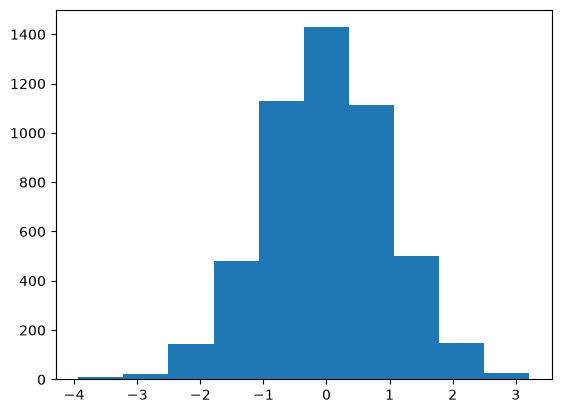

In [51]:
plt.hist(amostra_normalizada)

### Bernoulli

In [8]:
p = 0.5

amostra_bernoulli = amostras_uniformes < p

In [9]:
amostra_normalizada_bernoullis = normalizar_amostra(amostra_bernoulli, n, 0.5, 0.25)

(array([  13.,   56.,  310.,  790., 1282., 1316.,  827.,  312.,   80.,
          14.]),
 array([-3.54175098, -2.84604989, -2.15034881, -1.45464772, -0.75894664,
        -0.06324555,  0.63245553,  1.32815662,  2.0238577 ,  2.71955879,
         3.41525987]),
 <BarContainer object of 10 artists>)

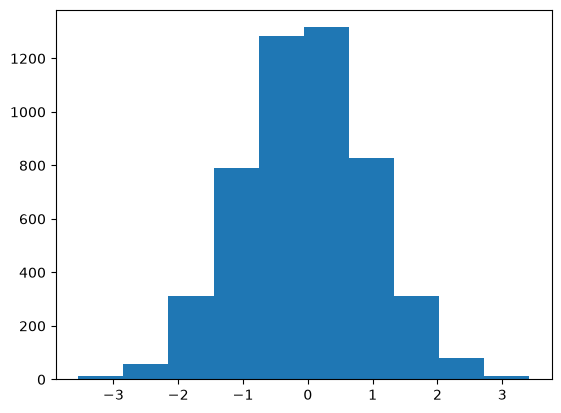

In [10]:
plt.hist(amostra_normalizada_bernoullis)

### Geométrica

In [12]:
p = 0.5
amostras_geometricas = np.floor(np.log(1-amostras_uniformes)/np.log(1-p)) + 1


In [13]:
amostras_geometricas_normalizadas = normalizar_amostra(amostras_geometricas, n, 2, 2)

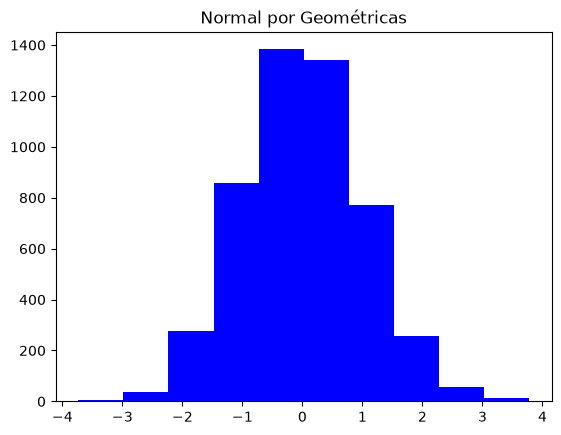

In [15]:
plt.hist(amostras_geometricas_normalizadas, color="blue")
plt.title("Normal por Geométricas")
plt.show()

### Poisson

In [31]:
lmbd = 5
amostras_poisson = []
for _ in tqdm(range(M), desc='Gerando Amostras'):
    amostra_1_poisson = []
    for _ in range(n):
        u = np.random.uniform()
        i = 0
        p0 = np.exp(-lmbd)
        F = p0
        while u > F:
            i += 1
            p0 *= (lmbd/i)
            F += p0
        amostra_1_poisson.append(i)
    amostras_poisson.append(amostra_1_poisson)


Gerando Amostras: 100%|██████████| 5000/5000 [02:16<00:00, 36.53it/s]


(array([5.000e+00, 2.300e+01, 2.150e+02, 6.930e+02, 1.511e+03, 1.554e+03,
        7.680e+02, 2.060e+02, 2.400e+01, 1.000e+00]),
 array([-4.24264069, -3.39552676, -2.54841284, -1.70129892, -0.85418499,
        -0.00707107,  0.84004286,  1.68715678,  2.5342707 ,  3.38138463,
         4.22849855]),
 <BarContainer object of 10 artists>)

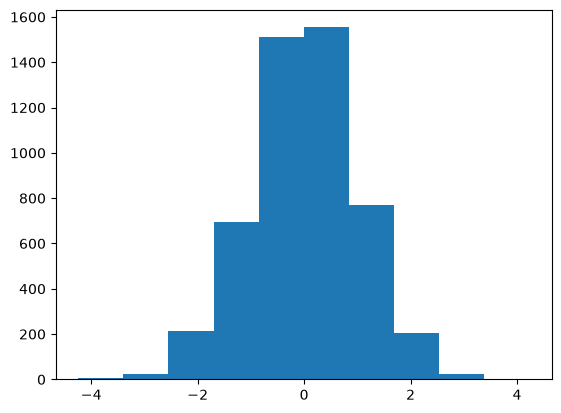

In [33]:
amostra_poisson_normalizada = normalizar_amostra(amostras_poisson, n, 5, 5)
plt.hist(amostra_poisson_normalizada)

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

In [44]:
normais = np.random.normal(0, 1, size=5000)

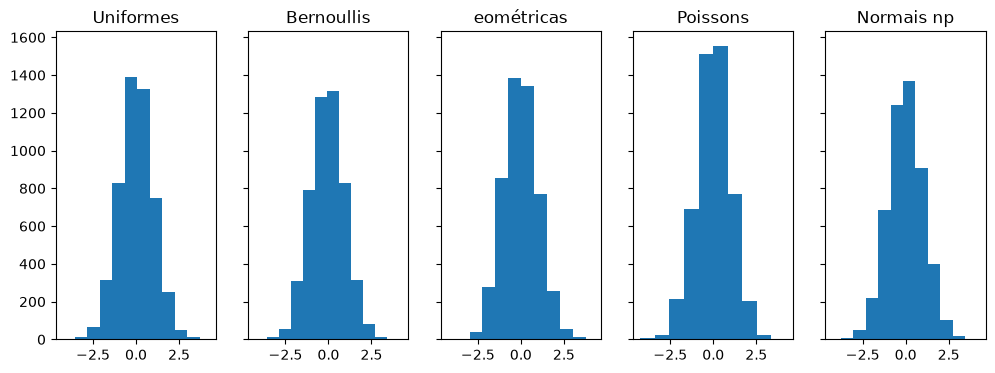

In [45]:
fig, ax = plt.subplots(1,5, figsize= (12,4), sharex=True, sharey=True)

ax[0].hist(amostra_normalizada)
ax[0].set_title('Uniformes')

ax[1].hist(amostra_normalizada_bernoullis)
ax[1].set_title('Bernoullis')

ax[2].hist(amostras_geometricas_normalizadas)
ax[2].set_title('eométricas')

ax[3].hist(amostra_poisson_normalizada)
ax[3].set_title('Poissons')

ax[4].hist(normais)
ax[4].set_title('Normais np')

plt.show()

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.

1- Conforme o n aumenta, as distribuições vão se aproximar cada vez mais da normal(0,1). 
2- A distribuição que converge mais rápido para a Normal é a uniforme, já que ela é simétrica e contínua
3- O formato da dist original influencia a aproximação pois para valores de n pequenos, vai "viesar" o gráfico e se parecer com sua própria forma original

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.